### **Nabilla Wulandari		 	 8020230008**
### **Fadillah Dwi Cahyanti  8020230023**
### **Revi Febrianti				 8020230084**

 Tahap 1: Persiapan Lingkungan dan Import Library

Install Library

In [1]:
# Install library jika belum tersedia
!pip install scikit-learn pandas numpy seaborn matplotlib imbalanced-learn requests kagglehub mlflow joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import joblib

from imblearn.pipeline import Pipeline

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    RFE,
    SelectFromModel
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Tahap 1. Persiapan Lingkungan dan Import Library

Pada tahap ini dilakukan instalasi dan import library yang akan digunakan selama proses analisis. Library yang digunakan mencakup pengolahan data, visualisasi, preprocessing, feature selection, evaluasi model, cross validation, hyperparameter tuning, hingga deployment model. Seluruh library berhasil dimuat sehingga proses analisis dapat dilanjutkan ke tahap berikutnya.

Tahap 2: Pengumpulan dan Load Dataset

In [2]:
# Download Dataset IoT Vulnerability Dataset
url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"
file_name = "Preprocessed_Balanced_dataset.csv"

print(f"Downloading {file_name}...")
response = requests.get(url)

if response.status_code == 200:
    with open(file_name, "wb") as f:
        f.write(response.content)
    print(f"{file_name} berhasil diunduh.\n")
else:
    print(f"Gagal mengunduh {file_name}. Status code: {response.status_code}\n")

# Load Dataset
df = pd.read_csv(file_name)
display(df.head())

Preprocessed_Balanced_dataset.csv berhasil diunduh.



,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


### Interpretasi Hasil

Dataset berhasil dimuat dengan baik dan terdiri dari berbagai fitur yang merepresentasikan karakteristik lalu lintas jaringan. Data ini akan digunakan untuk mengidentifikasi kategori serangan pada perangkat IoT.

Tahap 3: Exploratory Data Analysis (EDA)

Informasi & Statistik Dataset:

In [3]:
df.info(), df.describe(), df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                                                      104

(None,
                 dur      Protocol        Length   Source Host  \
 count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
 mean   4.171936e-02  2.142777e+01  1.122461e+02  5.407739e+04   
 std    1.914513e-01  1.107721e+01  2.385786e+02  3.109492e+04   
 min   -1.606545e-02  0.000000e+00  4.200000e+01  0.000000e+00   
 25%    9.790000e-05  1.100000e+01  4.200000e+01  5.746800e+04   
 50%    3.162750e-04  3.000000e+01  6.000000e+01  6.067100e+04   
 75%    2.474092e-03  3.000000e+01  7.400000e+01  6.067700e+04   
 max    7.973827e+00  3.500000e+01  5.858000e+03  1.449670e+05   
 
        Destination Host  Sender IP address  Target IP address        Opcode  \
 count      1.048575e+06       1.048575e+06       1.048575e+06  1.048575e+06   
 mean       3.146737e+03       1.291301e+00       1.740716e+00  9.528074e-01   
 std        1.511347e+03       1.921420e+00       4.199544e+00  5.890998e-01   
 min        0.000000e+00       0.000000e+00       0.000000e+00  0.000000e+00 

Visualisasi Distribusi Label:

### Interpretasi Hasil

Berdasarkan hasil pemeriksaan struktur data, dataset terdiri dari 1.048.575 baris dan 88 kolom yang menunjukkan jumlah data yang cukup besar untuk proses pelatihan model machine learning. Sebagian besar fitur memiliki tipe data numerik, yaitu 65 kolom bertipe integer dan 22 kolom bertipe float, sehingga dapat langsung digunakan dalam proses pemodelan setelah tahap preprocessing.

Hasil pengecekan nilai kosong menunjukkan bahwa seluruh kolom memiliki jumlah data yang sama dengan jumlah observasi, yaitu 1.048.575 data. Hal ini mengindikasikan bahwa tidak terdapat missing value pada dataset sehingga tidak diperlukan proses imputasi atau penghapusan data.

Berdasarkan statistik deskriptif, terdapat variasi nilai yang cukup besar antar fitur. Perbedaan rentang nilai ini menunjukkan bahwa proses standardisasi diperlukan agar setiap fitur memiliki skala yang lebih seimbang sebelum dilakukan feature selection dan pelatihan model. Selain itu, ukuran dataset yang besar diharapkan dapat membantu model mempelajari pola serangan IoT dengan lebih baik dan menghasilkan performa klasifikasi yang stabil.

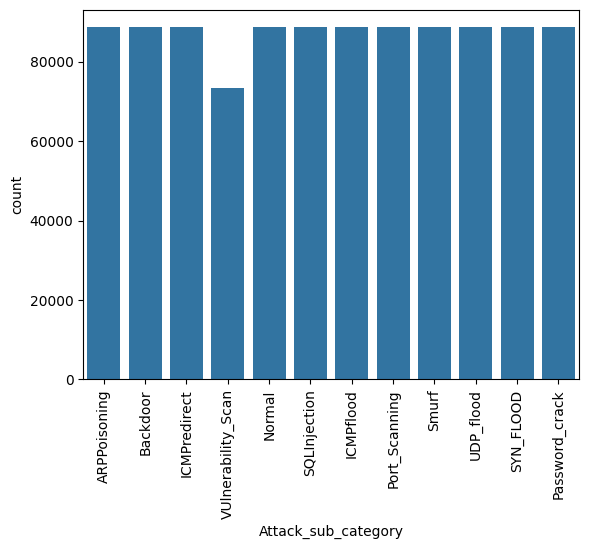

In [4]:
sns.countplot(data=df ,x='Attack_sub_category')
plt.xticks(rotation=90)
plt.show()

### Interpretasi Hasil

Berdasarkan visualisasi distribusi kelas, sebagian besar kategori serangan memiliki jumlah data yang relatif sama, yaitu sekitar 88 ribu hingga 89 ribu data per kategori. Hal ini menunjukkan bahwa dataset telah melalui proses balancing sehingga distribusi data antar kelas menjadi lebih merata.

Namun, kategori **Vulnerability_Scan** memiliki jumlah data yang sedikit lebih rendah dibandingkan kategori lainnya. Meskipun demikian, perbedaannya tidak terlalu signifikan sehingga dataset masih dapat dianggap cukup seimbang untuk proses pelatihan model.

Distribusi kelas yang relatif seimbang ini diharapkan dapat membantu model mempelajari pola setiap kategori serangan dengan lebih baik dan mengurangi risiko bias prediksi terhadap kelas tertentu. Oleh karena itu, metrik evaluasi seperti Accuracy, Precision, Recall, dan F1-Score dapat digunakan untuk membandingkan performa model secara lebih adil.

Analisis Korelasi:

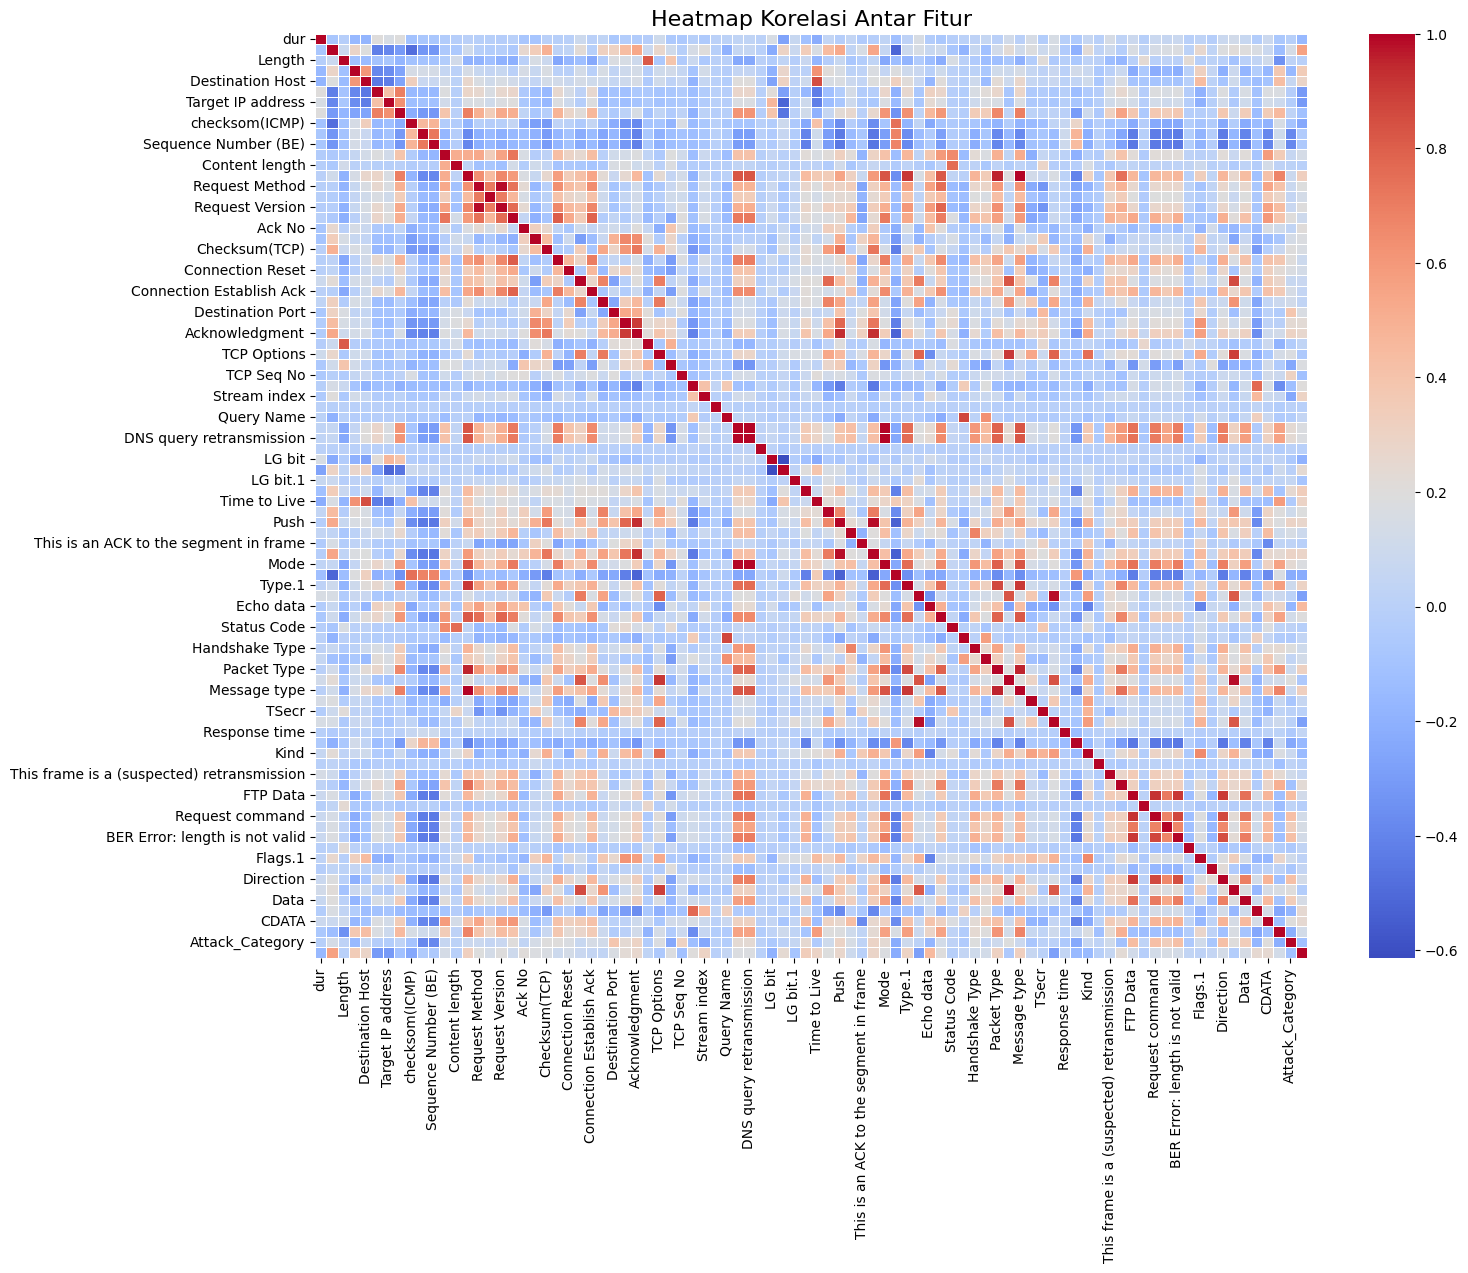

In [19]:
# Analisis Korelasi Antar Fitur

# Menghitung matriks korelasi
corr_matrix = df.corr(numeric_only=True)

# Membuat visualisasi heatmap
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=False,      # ubah menjadi True jika ingin menampilkan angka korelasi
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Fitur", fontsize=16)
plt.show()

### Interpretasi Hasil

Berdasarkan heatmap korelasi, terlihat bahwa beberapa fitur memiliki hubungan yang cukup kuat, sementara sebagian besar fitur lainnya memiliki korelasi rendah. Hal ini menunjukkan bahwa terdapat fitur yang kemungkinan menyimpan informasi yang mirip.

Karena jumlah fitur pada dataset cukup banyak, yaitu 88 fitur, maka feature selection perlu dilakukan untuk memilih fitur yang paling relevan dan mengurangi fitur yang kurang berpengaruh terhadap proses klasifikasi. Dengan demikian, model dapat bekerja lebih efisien tanpa harus menggunakan seluruh fitur yang tersedia.

 Tahap 4: Preprocessing Data

In [20]:
# ================================
# Preprocessing
# ================================

target_column = df.columns[-1]

# Label Encoding target
le = LabelEncoder()
df[target_column] = le.fit_transform(df[target_column])

# Kolom yang tidak boleh menjadi fitur
drop_cols = [
    target_column,
    "Label",
    "Attack_Category",
    "Attack_sub_category"
]

# Ambil fitur
X = df.drop(
    columns=[c for c in drop_cols if c in df.columns],
    errors="ignore"
)

# Target
y = df[target_column]

# Ambil hanya fitur numerik
X = X.select_dtypes(
    include=["int64", "float64"]
)

print("Jumlah fitur:", len(X.columns))
print("Apakah ada Label?", "Label" in X.columns)
print("Apakah ada Attack_Category?", "Attack_Category" in X.columns)
print("Apakah ada Attack_sub_category?", "Attack_sub_category" in X.columns)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Jumlah fitur: 85
Apakah ada Label? False
Apakah ada Attack_Category? False
Apakah ada Attack_sub_category? False


### Preprocessing Data

Pada tahap preprocessing, kolom target ditentukan sebagai kolom terakhir pada dataset, yaitu **Attack_sub_category**. Variabel target kemudian diubah ke bentuk numerik menggunakan **Label Encoding** agar dapat diproses oleh algoritma machine learning.

Selanjutnya dilakukan pemisahan antara fitur (**X**) dan target (**y**). Untuk mencegah **data leakage**, kolom **Label**, **Attack_Category**, dan **Attack_sub_category** tidak digunakan sebagai fitur karena ketiga kolom tersebut mengandung informasi label yang dapat memengaruhi hasil prediksi secara tidak valid.

Setelah itu hanya fitur dengan tipe data numerik (`int64` dan `float64`) yang digunakan dalam proses pemodelan. Hasil preprocessing menghasilkan **85 fitur numerik** yang digunakan sebagai variabel input model.

Dataset kemudian dibagi menjadi data latih (**80%**) dan data uji (**20%**) menggunakan metode **Stratified Train-Test Split** dengan `random_state=42`. Teknik stratifikasi digunakan untuk menjaga proporsi setiap kelas serangan tetap seimbang pada data latih maupun data uji sehingga evaluasi model menjadi lebih representatif.

Tahap 5: Implementasi Pipeline & Cross Validation (Metode Inti)

A. Pipeline 1: Filter Method (Contoh: SelectKBest)

In [7]:
pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

### Implementasi Filter Method

Pada metode Filter, dipilih 10 fitur terbaik dari seluruh fitur yang tersedia pada dataset. Pemilihan dilakukan untuk mengurangi jumlah fitur yang digunakan oleh model sehingga proses pelatihan menjadi lebih efisien. Fitur yang memiliki skor tertinggi akan dipertahankan, sedangkan fitur dengan skor yang lebih rendah tidak digunakan pada proses klasifikasi.

B. Pipeline 2: Wrapper Method

In [8]:
pipeline_wrapper = Pipeline([
    ('scaler', StandardScaler()),
    
    ('feature_selection', RFE(
        estimator=RandomForestClassifier(
            n_estimators=10,
            max_depth=5,
            random_state=42,
            n_jobs=1
        ),
        n_features_to_select=10
    )),
    
    ('model', RandomForestClassifier(
        n_estimators=10,
        max_depth=5,
        random_state=42,
        n_jobs=1
    ))
])

### Implementasi Wrapper Method

Pada metode Wrapper, dipilih 10 fitur terbaik melalui proses eliminasi bertahap menggunakan Random Forest sebagai estimator. Fitur yang dianggap kurang berkontribusi terhadap performa model akan dihapus secara bertahap hingga tersisa 10 fitur yang paling relevan untuk proses klasifikasi.

C. Pipeline 3: Embedded Method (Contoh: SelectFromModel)

In [9]:
pipeline_embedded = Pipeline([
    ('scaler', StandardScaler()),
    
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(
            n_estimators=5,
            max_depth=3,
            random_state=42,
            n_jobs=1
        )
    )),
    
    ('model', RandomForestClassifier(
        n_estimators=20,
        max_depth=5,
        random_state=42,
        n_jobs=1
    ))
])

### Implementasi Embedded Method

Pada metode Embedded, proses seleksi fitur dilakukan secara langsung oleh model Random Forest melalui nilai feature importance yang dihasilkan selama pelatihan. Fitur yang memiliki kontribusi rendah akan dieliminasi, sedangkan fitur yang dianggap penting akan dipertahankan untuk proses klasifikasi.

 Tahap 6: Evaluasi Cross Validation

In [10]:
# ============================================
# SETUP CROSS VALIDATION
# ============================================
from sklearn.model_selection import cross_validate, StratifiedKFold

# Cross Validation Strategy
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scoring = [
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro'
]

### Setup Cross Validation

Evaluasi model dilakukan menggunakan Stratified K-Fold Cross Validation dengan 3 fold. Penggunaan stratified sampling bertujuan untuk menjaga proporsi setiap kategori serangan tetap seimbang pada setiap fold. Selain itu, jumlah fold dipilih sebanyak 3 untuk mempercepat proses evaluasi karena ukuran dataset yang cukup besar, sementara tetap mempertahankan hasil evaluasi yang representatif.

In [11]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

cv_results_filter = cross_validate(
    pipeline_filter,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        'accuracy',
        'precision_macro',
        'recall_macro',
        'f1_macro'
    ]
)

print("=== FILTER METHOD ===")
print(f"Mean Accuracy : {cv_results_filter['test_accuracy'].mean():.4f}")
print(f"Mean Precision: {cv_results_filter['test_precision_macro'].mean():.4f}")
print(f"Mean Recall   : {cv_results_filter['test_recall_macro'].mean():.4f}")
print(f"Mean F1 Score : {cv_results_filter['test_f1_macro'].mean():.4f}")

=== FILTER METHOD ===
Mean Accuracy : 0.8435
Mean Precision: 0.9178
Mean Recall   : 0.8419
Mean F1 Score : 0.8236


### Analisis Hasil Filter Method

Berdasarkan hasil cross validation, metode Filter menghasilkan Accuracy sebesar 84,35%. Hasil ini menunjukkan bahwa 10 fitur yang dipilih masih mampu digunakan untuk proses klasifikasi tanpa menggunakan seluruh fitur pada dataset.

Nilai Precision yang lebih tinggi dibandingkan Recall menunjukkan bahwa prediksi yang dihasilkan model cenderung tepat, namun masih terdapat beberapa data serangan yang belum berhasil dikenali dengan baik. Hal ini juga terlihat dari nilai F1-Score yang masih berada di bawah nilai Accuracy.

Hasil tersebut menunjukkan bahwa fitur yang dipilih melalui metode Filter telah mampu mempertahankan informasi penting dalam dataset, namun masih terdapat kemungkinan bahwa beberapa fitur yang dihilangkan memiliki kontribusi terhadap peningkatan performa model. Oleh karena itu, diperlukan pengujian menggunakan metode Wrapper dan Embedded untuk melihat apakah pemilihan fitur yang berbeda dapat menghasilkan performa yang lebih baik.

In [12]:
cv_results_wrapper = cross_validate(
    pipeline_wrapper,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring=scoring,
    n_jobs=2
)

print("\nWRAPPER METHOD")
print("Accuracy :", cv_results_wrapper['test_accuracy'].mean())
print("Precision:", cv_results_wrapper['test_precision_macro'].mean())
print("Recall   :", cv_results_wrapper['test_recall_macro'].mean())
print("F1 Score :", cv_results_wrapper['test_f1_macro'].mean())


WRAPPER METHOD
Accuracy : 0.9067782466680973
Precision: 0.8890303119070916
Recall   : 0.8968378460357872
F1 Score : 0.8718147327726459


### Analisis Hasil Wrapper Method

Berdasarkan hasil cross validation, metode Wrapper menghasilkan Accuracy sebesar 90,68% dan F1-Score sebesar 87,18%. Hasil ini lebih baik dibandingkan metode Filter yang sebelumnya memperoleh Accuracy 84,35% dan F1-Score 82,36%.

Peningkatan performa tersebut menunjukkan bahwa fitur yang dipilih oleh metode Wrapper lebih relevan dalam membedakan kategori serangan pada dataset. Fitur-fitur yang dieliminasi kemungkinan memiliki kontribusi yang lebih kecil terhadap proses klasifikasi, sehingga pengurangan jumlah fitur tidak menurunkan performa model.

Hasil ini menunjukkan bahwa metode Wrapper mampu memilih kombinasi fitur yang lebih efektif dibandingkan metode Filter dan berpotensi memberikan performa yang lebih baik pada proses klasifikasi.

In [17]:
# Embedded Method
cv_results_embedded = cross_validate(
    pipeline_embedded,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    n_jobs=1
)

print("\nEMBEDDED METHOD")
print("Accuracy :", cv_results_embedded['test_accuracy'].mean())
print("Precision:", cv_results_embedded['test_precision_macro'].mean())
print("Recall   :", cv_results_embedded['test_recall_macro'].mean())
print("F1 Score :", cv_results_embedded['test_f1_macro'].mean())


EMBEDDED METHOD
Accuracy : 0.9626016260162601
Precision: 0.9725413809534665
Recall   : 0.9625426096455726
F1 Score : 0.9606544589065237


### Analisis Hasil Embedded Method

Berdasarkan hasil cross validation, metode Embedded menghasilkan performa terbaik dibandingkan metode Filter dan Wrapper. Accuracy yang diperoleh mencapai 96,26% dengan F1-Score sebesar 96,07%, menunjukkan bahwa fitur yang dipilih mampu merepresentasikan karakteristik setiap kategori serangan dengan sangat baik.

Peningkatan performa yang cukup signifikan dibandingkan metode sebelumnya menunjukkan bahwa fitur-fitur yang dieliminasi memiliki kontribusi yang lebih kecil terhadap proses klasifikasi. Sebaliknya, fitur yang dipertahankan oleh metode Embedded mampu memberikan informasi yang lebih relevan sehingga model dapat mengenali pola serangan dengan lebih akurat.

Hasil ini menunjukkan bahwa metode Embedded lebih efektif dalam melakukan seleksi fitur pada dataset IoT Vulnerability. Oleh karena itu, metode ini dipilih sebagai metode feature selection terbaik dan digunakan pada tahap Hyperparameter Tuning.

      Metric    Filter   Wrapper  Embedded
0   Accuracy  0.843541  0.906778  0.962602
1  Precision  0.917761  0.889030  0.972541
2     Recall  0.841894  0.896838  0.962543
3   F1 Score  0.823577  0.871815  0.960654


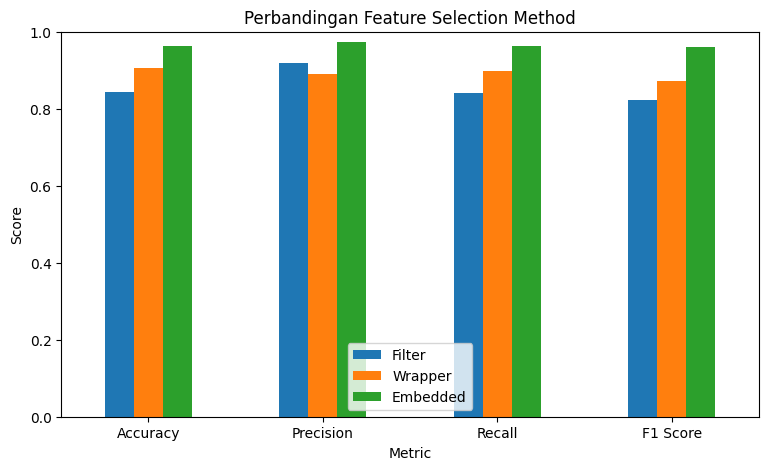

In [14]:
# Perbandingan semua metode feature selection
results_compare = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    
    'Filter': [
        cv_results_filter['test_accuracy'].mean(),
        cv_results_filter['test_precision_macro'].mean(),
        cv_results_filter['test_recall_macro'].mean(),
        cv_results_filter['test_f1_macro'].mean()
    ],
    
    'Wrapper': [
        cv_results_wrapper['test_accuracy'].mean(),
        cv_results_wrapper['test_precision_macro'].mean(),
        cv_results_wrapper['test_recall_macro'].mean(),
        cv_results_wrapper['test_f1_macro'].mean()
    ],
    
    'Embedded': [
        cv_results_embedded['test_accuracy'].mean(),
        cv_results_embedded['test_precision_macro'].mean(),
        cv_results_embedded['test_recall_macro'].mean(),
        cv_results_embedded['test_f1_macro'].mean()
    ]
})

# Tampilkan tabel
print(results_compare)

# Bar Chart
results_compare.plot(
    x='Metric',
    kind='bar',
    figsize=(9,5)
)

plt.title('Perbandingan Feature Selection Method')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0,1)

plt.show()

### Analisis Perbandingan Metode Feature Selection

Berdasarkan hasil cross validation, metode Embedded memberikan performa terbaik pada seluruh metrik evaluasi. Metode ini memperoleh Accuracy sebesar 96,26%, Precision sebesar 97,25%, Recall sebesar 96,25%, dan F1-Score sebesar 96,07%.

Metode Wrapper berada pada posisi kedua dengan Accuracy sebesar 90,68% dan F1-Score sebesar 87,18%. Hasil ini menunjukkan bahwa proses eliminasi fitur secara bertahap mampu meningkatkan performa model dibandingkan metode Filter.

Sementara itu, metode Filter menghasilkan performa paling rendah dengan Accuracy sebesar 84,35% dan F1-Score sebesar 82,36%. Hasil tersebut menunjukkan bahwa pemilihan fitur berdasarkan skor statistik saja belum mampu menghasilkan kombinasi fitur yang optimal untuk proses klasifikasi.

Berdasarkan perbandingan tersebut, metode Embedded dipilih sebagai metode feature selection terbaik karena mampu menghasilkan performa tertinggi pada seluruh metrik evaluasi. Hal ini menunjukkan bahwa fitur yang dipertahankan oleh metode Embedded lebih relevan dalam membedakan kategori serangan dibandingkan fitur yang dipilih oleh metode Filter maupun Wrapper.

Tahap 7: Hyperparameter Tuning

RandomizedSearchCV

In [15]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter tuning
param_dist = {
    'feature_selection__estimator__n_estimators': [5, 10, 20],
    'feature_selection__estimator__max_depth': [3, 5, 7],

    'model__n_estimators': [5, 10, 20],
    'model__max_depth': [3, 5, 7]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=pipeline_embedded,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

# Training tuning
random_search.fit(X_train, y_train)

# Hasil terbaik
print("Best Score :", random_search.best_score_)
print("Best Params:", random_search.best_params_)

Best Score : 0.9568998402593997
Best Params: {'model__n_estimators': 10, 'model__max_depth': 5, 'feature_selection__estimator__n_estimators': 5, 'feature_selection__estimator__max_depth': 5}


### Analisis Hyperparameter Tuning

Berdasarkan hasil Randomized Search, kombinasi parameter terbaik diperoleh pada `model__n_estimators = 10`, `model__max_depth = 5`, `feature_selection__estimator__n_estimators = 5`, dan `feature_selection__estimator__max_depth = 5` dengan nilai accuracy cross validation sebesar 95,69%.

Hasil ini menunjukkan bahwa model tidak memerlukan jumlah pohon yang terlalu banyak maupun kedalaman pohon yang terlalu besar untuk menghasilkan performa yang optimal. Kombinasi parameter tersebut mampu memberikan keseimbangan antara kemampuan model dalam mempelajari pola data dan menghindari kompleksitas yang berlebihan.

Berdasarkan hasil tuning, konfigurasi parameter terbaik ini dipilih untuk digunakan pada tahap evaluasi akhir menggunakan data uji serta pada proses deployment model.

Tahap 8: Evaluasi Akhir (Test Set)

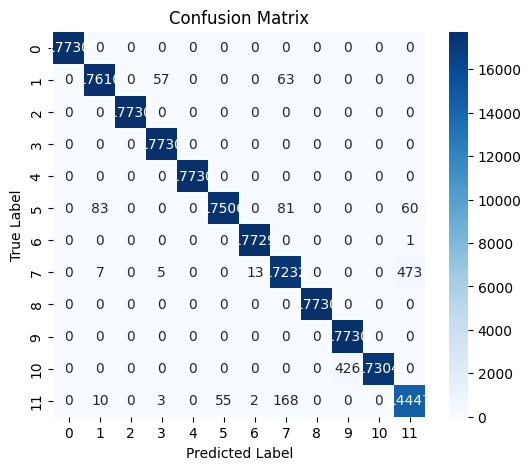


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17730
           1       0.99      0.99      0.99     17730
           2       1.00      1.00      1.00     17730
           3       1.00      1.00      1.00     17730
           4       1.00      1.00      1.00     17730
           5       1.00      0.99      0.99     17730
           6       1.00      1.00      1.00     17730
           7       0.98      0.97      0.98     17730
           8       1.00      1.00      1.00     17730
           9       0.98      1.00      0.99     17730
          10       1.00      0.98      0.99     17730
          11       0.96      0.98      0.97     14685

    accuracy                           0.99    209715
   macro avg       0.99      0.99      0.99    209715
weighted avg       0.99      0.99      0.99    209715


Model berhasil disimpan sebagai pipeline_terbaik.pkl


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Gunakan model terbaik hasil tuning
best_model = random_search.best_estimator_

# Prediksi data test
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# Simpan model terbaik
joblib.dump(best_model, 'pipeline_terbaik.pkl')

print("\nModel berhasil disimpan sebagai pipeline_terbaik.pkl")

### Analisis Confusion Matrix

Berdasarkan confusion matrix, sebagian besar data berhasil diklasifikasikan pada kategori yang benar. Hal ini terlihat dari dominasi nilai pada diagonal utama yang menunjukkan jumlah prediksi benar jauh lebih besar dibandingkan kesalahan prediksi.

Kesalahan klasifikasi masih ditemukan pada beberapa kategori, terutama pada label 7, 10, dan 11. Namun jumlah kesalahan tersebut relatif kecil dibandingkan total data pada masing-masing kategori. Secara keseluruhan, model mampu membedakan kategori serangan dengan sangat baik dan menghasilkan tingkat klasifikasi yang tinggi pada hampir seluruh kelas.

### Analisis Classification Report

Berdasarkan classification report, model menghasilkan performa yang sangat baik dengan accuracy sebesar 99%. Sebagian besar kategori serangan memperoleh nilai precision, recall, dan f1-score mendekati 1,00 yang menunjukkan bahwa model mampu mengenali dan membedakan setiap kategori serangan dengan sangat baik.

Meskipun masih terdapat sedikit kesalahan prediksi pada beberapa kategori, terutama pada label 7 dan 11, pengaruhnya terhadap performa keseluruhan model relatif kecil. Nilai macro average dan weighted average yang sama-sama mencapai 0,99 menunjukkan bahwa model memiliki performa yang stabil pada seluruh kategori serangan.

Hasil evaluasi ini menunjukkan bahwa kombinasi metode Embedded Feature Selection dan parameter terbaik hasil tuning mampu menghasilkan model yang akurat dan layak digunakan pada tahap deployment.

## Kesimpulan

Berdasarkan hasil perbandingan tiga metode feature selection, metode Embedded menghasilkan performa terbaik dengan Accuracy sebesar 96,26% pada tahap cross validation. Hasil tersebut lebih baik dibandingkan metode Wrapper maupun Filter, sehingga metode Embedded dipilih untuk tahap hyperparameter tuning.

Setelah dilakukan optimasi parameter menggunakan Randomized Search, model terbaik berhasil memperoleh performa yang sangat baik pada data uji dengan accuracy sebesar 99%. Hasil ini menunjukkan bahwa fitur yang dipilih oleh metode Embedded mampu mempertahankan informasi penting dalam dataset dan membantu model mengenali berbagai kategori serangan IoT dengan tingkat kesalahan yang sangat rendah.

Dengan demikian, metode Embedded Feature Selection dipilih sebagai pendekatan terbaik pada penelitian ini dan model yang dihasilkan berhasil disimpan dalam bentuk pipeline untuk digunakan pada tahap deployment menggunakan Streamlit.